<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/16_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Recommendation System**

**Data Preparation**

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("anime.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe(include="all"))

Dataset Shape: (12294, 7)

First 5 Rows:
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  

Data Types:
anime_id      int64
name         object
genre        object
type         object
episodes    

**Data Exploration and Missing Values**

In [11]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nAnime Types:")
print(df["type"].value_counts(dropna=False))

print("\nGenre Missing Values:", df["genre"].isnull().sum())
print("Rating Missing Values:", df["rating"].isnull().sum())
print("Episodes Missing Values:", df["episodes"].isnull().sum())

Missing Values:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Duplicate Rows: 0

Unique Values:
anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64

Anime Types:
type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
NaN          25
Name: count, dtype: int64

Genre Missing Values: 62
Rating Missing Values: 230
Episodes Missing Values: 0


**Data Preprocessing**

In [12]:

data = df.copy()

data["genre"] = data["genre"].fillna("Unknown")
data["type"] = data["type"].fillna("Unknown")
data["rating"] = data["rating"].fillna(data["rating"].median())
data["members"] = data["members"].fillna(data["members"].median())
data["episodes"] = data["episodes"].replace("Unknown", np.nan)
data["episodes"] = pd.to_numeric(data["episodes"], errors="coerce")
data["episodes"] = data["episodes"].fillna(data["episodes"].median())

data = data.drop_duplicates(subset="name").reset_index(drop=True)

print("Shape After Preprocessing:", data.shape)
print("\nRemaining Missing Values:")
print(data.isnull().sum())

Shape After Preprocessing: (12292, 7)

Remaining Missing Values:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


**Feature Extraction**

In [13]:

data["genre_list"] = data["genre"].apply(
    lambda x: [g.strip() for g in str(x).split(",")]
)

mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(data["genre_list"])

genre_df = pd.DataFrame(
    genre_features,
    columns=mlb.classes_,
    index=data.index
)

type_df = pd.get_dummies(
    data["type"],
    prefix="type"
).astype(int)

numeric_features = data[["rating", "members", "episodes"]].copy()

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_features)

numeric_df = pd.DataFrame(
    numeric_scaled,
    columns=["rating", "members", "episodes"],
    index=data.index
)

feature_matrix = pd.concat(
    [genre_df, type_df, numeric_df],
    axis=1
)

print("Feature Matrix Shape:", feature_matrix.shape)
print("\nFeature Matrix:")
print(feature_matrix.head())

Feature Matrix Shape: (12292, 54)

Feature Matrix:
   Action  Adventure  Cars  Comedy  Dementia  Demons  Drama  Ecchi  Fantasy  \
0       0          0     0       0         0       0      1      0        0   
1       1          1     0       0         0       0      1      0        1   
2       1          0     0       1         0       0      0      0        0   
3       0          0     0       0         0       0      0      0        0   
4       1          0     0       1         0       0      0      0        0   

   Game  ...  type_Movie  type_Music  type_ONA  type_OVA  type_Special  \
0     0  ...           1           0         0         0             0   
1     0  ...           0           0         0         0             0   
2     0  ...           0           0         0         0             0   
3     0  ...           0           0         0         0             0   
4     0  ...           0           0         0         0             0   

   type_TV  type_Unknown    r

**Cosine Similarity**

In [14]:

similarity_matrix = cosine_similarity(feature_matrix)

print("Cosine Similarity Matrix Shape:", similarity_matrix.shape)
print("\nSimilarity Matrix Sample:")
print(similarity_matrix[:5, :5])

Cosine Similarity Matrix Shape: (12292, 12292)

Similarity Matrix Sample:
[[1.         0.76715436 0.62078023 0.77637586 0.67327645]
 [0.76715436 1.         0.56108436 0.97529492 0.66570714]
 [0.62078023 0.56108436 1.         0.5608003  0.99028465]
 [0.77637586 0.97529492 0.5608003  1.         0.66575716]
 [0.67327645 0.66570714 0.99028465 0.66575716 1.        ]]


**Recommendation Function**

In [15]:

def recommend_anime(anime_name, n_recommendations=10, threshold=0.0):
    matches = data[
        data["name"].str.lower() == anime_name.lower()
    ]

    if matches.empty:
        print("Anime not found in the dataset.")
        return pd.DataFrame()

    index = matches.index[0]
    similarity_scores = similarity_matrix[index]

    similar_indices = np.argsort(similarity_scores)[::-1]
    similar_indices = [
        i for i in similar_indices
        if i != index and similarity_scores[i] >= threshold
    ]

    similar_indices = similar_indices[:n_recommendations]

    recommendations = data.loc[similar_indices, [
        "name", "genre", "type", "episodes", "rating", "members"
    ]].copy()

    recommendations["similarity_score"] = [
        similarity_scores[i] for i in similar_indices
    ]

    return recommendations.reset_index(drop=True)

example_anime = data["name"].iloc[0]

print("Target Anime:", example_anime)
print("\nRecommendations:")
print(recommend_anime(example_anime, n_recommendations=10))

Target Anime: Kimi no Na wa.

Recommendations:
                                                name  \
0                                 Hotarubi no Mori e   
1                      Suzumiya Haruhi no Shoushitsu   
2                                     Hotaru no Haka   
3  Clannad: After Story - Mou Hitotsu no Sekai, K...   
4                                   Kotonoha no Niwa   
5  Yahari Ore no Seishun Love Comedy wa Machigatt...   
6                                Howl no Ugoku Shiro   
7                              Toki wo Kakeru Shoujo   
8          Clannad: Mou Hitotsu no Sekai, Tomoyo-hen   
9                                     Koe no Katachi   

                                               genre     type  episodes  \
0               Drama, Romance, Shoujo, Supernatural    Movie       1.0   
1  Comedy, Mystery, Romance, School, Sci-Fi, Supe...    Movie       1.0   
2                                  Drama, Historical    Movie       1.0   
3                             Drama,

**Similarity Threshold Experiment**

In [16]:

target_anime = data["name"].iloc[0]

thresholds = [0.20, 0.40, 0.60, 0.80]

for threshold in thresholds:
    recommendations = recommend_anime(
        target_anime,
        n_recommendations=20,
        threshold=threshold
    )

    print("\nSimilarity Threshold:", threshold)
    print("Number of Recommendations:", len(recommendations))
    print(recommendations[["name", "similarity_score"]].head(10))


Similarity Threshold: 0.2
Number of Recommendations: 20
                                                name  similarity_score
0                                 Hotarubi no Mori e          0.946313
1                      Suzumiya Haruhi no Shoushitsu          0.912240
2                                     Hotaru no Haka          0.900629
3  Clannad: After Story - Mou Hitotsu no Sekai, K...          0.892061
4                                   Kotonoha no Niwa          0.890165
5  Yahari Ore no Seishun Love Comedy wa Machigatt...          0.886351
6                                Howl no Ugoku Shiro          0.883177
7                              Toki wo Kakeru Shoujo          0.881346
8          Clannad: Mou Hitotsu no Sekai, Tomoyo-hen          0.873269
9                                     Koe no Katachi          0.872686

Similarity Threshold: 0.4
Number of Recommendations: 20
                                                name  similarity_score
0                                 

**Recommendation Performance Analysis**

   Threshold  Recommendations  Average Similarity
0        0.0               20            0.878502
1        0.1               20            0.878502
2        0.2               20            0.878502
3        0.3               20            0.878502
4        0.4               20            0.878502
5        0.5               20            0.878502
6        0.6               20            0.878502
7        0.7               20            0.878502
8        0.8               20            0.878502
9        0.9                3            0.919728


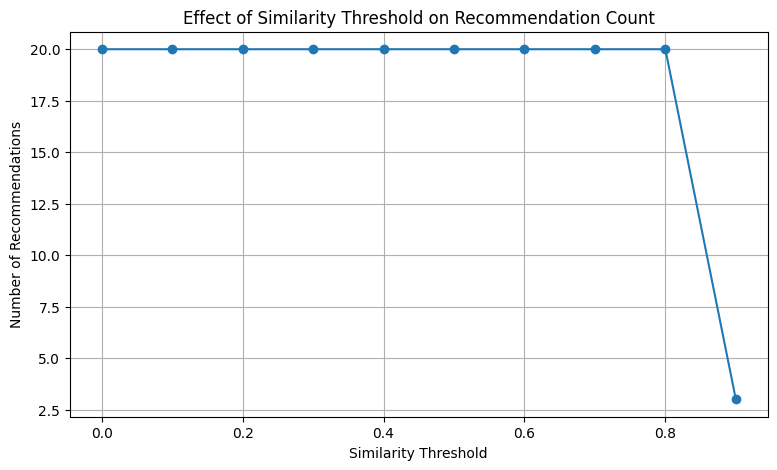

In [17]:

target_anime = data["name"].iloc[0]

performance_results = []

for threshold in np.arange(0.0, 1.0, 0.1):
    recommendations = recommend_anime(
        target_anime,
        n_recommendations=20,
        threshold=threshold
    )

    performance_results.append({
        "Threshold": round(threshold, 1),
        "Recommendations": len(recommendations),
        "Average Similarity": recommendations["similarity_score"].mean()
        if not recommendations.empty else 0
    })

performance_df = pd.DataFrame(performance_results)

print(performance_df)

plt.figure(figsize=(9, 5))
plt.plot(
    performance_df["Threshold"],
    performance_df["Recommendations"],
    marker="o"
)
plt.xlabel("Similarity Threshold")
plt.ylabel("Number of Recommendations")
plt.title("Effect of Similarity Threshold on Recommendation Count")
plt.grid()
plt.show()

**Recommendation Quality Analysis**

In [18]:

recommendations = recommend_anime(
    data["name"].iloc[0],
    n_recommendations=10,
    threshold=0.5
)

print("Recommendations with Similarity >= 0.5:")
print(recommendations)

if not recommendations.empty:
    print("\nAverage Similarity Score:",
          recommendations["similarity_score"].mean())
    print("Highest Similarity Score:",
          recommendations["similarity_score"].max())
    print("Lowest Similarity Score:",
          recommendations["similarity_score"].min())

print("\nAreas for Improvement:")
print("1. Add user-specific rating history.")
print("2. Use collaborative filtering for personalized recommendations.")
print("3. Improve handling of sparse or missing genre information.")
print("4. Combine content-based and collaborative filtering.")
print("5. Evaluate recommendations using user feedback.")

Recommendations with Similarity >= 0.5:
                                                name  \
0                                 Hotarubi no Mori e   
1                      Suzumiya Haruhi no Shoushitsu   
2                                     Hotaru no Haka   
3  Clannad: After Story - Mou Hitotsu no Sekai, K...   
4                                   Kotonoha no Niwa   
5  Yahari Ore no Seishun Love Comedy wa Machigatt...   
6                                Howl no Ugoku Shiro   
7                              Toki wo Kakeru Shoujo   
8          Clannad: Mou Hitotsu no Sekai, Tomoyo-hen   
9                                     Koe no Katachi   

                                               genre     type  episodes  \
0               Drama, Romance, Shoujo, Supernatural    Movie       1.0   
1  Comedy, Mystery, Romance, School, Sci-Fi, Supe...    Movie       1.0   
2                                  Drama, Historical    Movie       1.0   
3                             Drama, Romanc

##**User-Based vs Item-Based Collaborative Filtering**
**User-based collaborative filtering** recommends items by finding users who have similar preferences and then recommending items liked by those similar users.

**Item-based collaborative filtering** finds items that are similar based on users' interactions or ratings and recommends items similar to those the user already likes.
**Difference:** User-based filtering focuses on similarities between users, while item-based filtering focuses on similarities between items.

##**Collaborative Filtering**
* Collaborative filtering is a recommendation technique that uses user-item interactions, such as ratings, purchases, or viewing history, to generate recommendations.

* It works by identifying patterns in user behavior. Users with similar preferences can be used to recommend items to each other, or items with similar interaction patterns can be recommended to users.

* The current assignment implements **content-based recommendation using cosine similarity**, using anime attributes such as genres, type, rating, members, and episodes. Collaborative filtering is included here for the required interview question rather than being used as the main recommendation algorithm. The assignment specifically asks the main system to use cosine similarity.